# Parcial II - Aprendizaje de Maquina
### Clasificacion de Digitos MNIST: Clases 1, 6 y 7

**Asignatura:** Aprendizaje de Maquina y Analisis de Datos  
**Docente:** Felipe Palta

El objetivo de este parcial es clasificar los digitos 1, 6 y 7 del dataset MNIST usando tres modelos de aprendizaje de maquina vistos en clase.

**Integrantes:**

1.   Santiago Arango / sarangoh@javerianacali.edu.co
2.   Jhon Rios / jdriosa@javerianacali.edu.co
3.   Jhon Deiby Mejias / jhon0303@javerianacali.edu.co

**Fecha:** 20/04/2026

---
## Importaciones


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import ipywidgets as widgets
from IPython.display import display, clear_output

---
## Carga del Dataset MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

X = np.concatenate([x_train, x_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Clases:", np.unique(y))
print("Rango de intensidad:", X.min(), "a", X.max())

Forma de X: (70000, 28, 28)
Forma de y: (70000,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de intensidad: 0 a 255


---
## Librerias adicionales

In [ ]:
import seaborn as sns              # Visualización de datos estadísticos
import io, warnings         # io manejo de datos, warnings control de advertencias
warnings.filterwarnings('ignore')  # Ignora advertencias

from PIL import Image             # Manejo de imágenes
from skimage.feature import hog   # Extracción de características HOG
from skimage import exposure      # Ajuste de contraste en imágenes
import cv2                        # Procesamiento de imágenes con OpenCV

from sklearn.model_selection import train_test_split  # División de datos en train y test
from sklearn.preprocessing import StandardScaler      # Escalado de datos
from sklearn.svm import SVC                           # Modelo SVM
from sklearn.neighbors import KNeighborsClassifier    # Modelo KNN
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Métricas de evaluación

np.random.seed(42)              # Reproducibilidad

---
## Filtro de clases asignadas: 1, 6 y 7

In [ ]:
CLASES  = [1, 6, 7]
COLORES = ['#3498db', '#e74c3c', '#2ecc71']

mascara = np.isin(y, CLASES)
X_mnist = X[mascara].astype(np.float32)
y_mnist = y[mascara]

print(f'Total de muestras filtradas: {X_mnist.shape[0]}')
for c in CLASES:
    print(f'  Digito {c}: {np.sum(y_mnist == c)} muestras')

Total de muestras filtradas: 22046
  Digito 1: 7877 muestras
  Digito 6: 6876 muestras
  Digito 7: 7293 muestras


---
## Visualizacion inicial

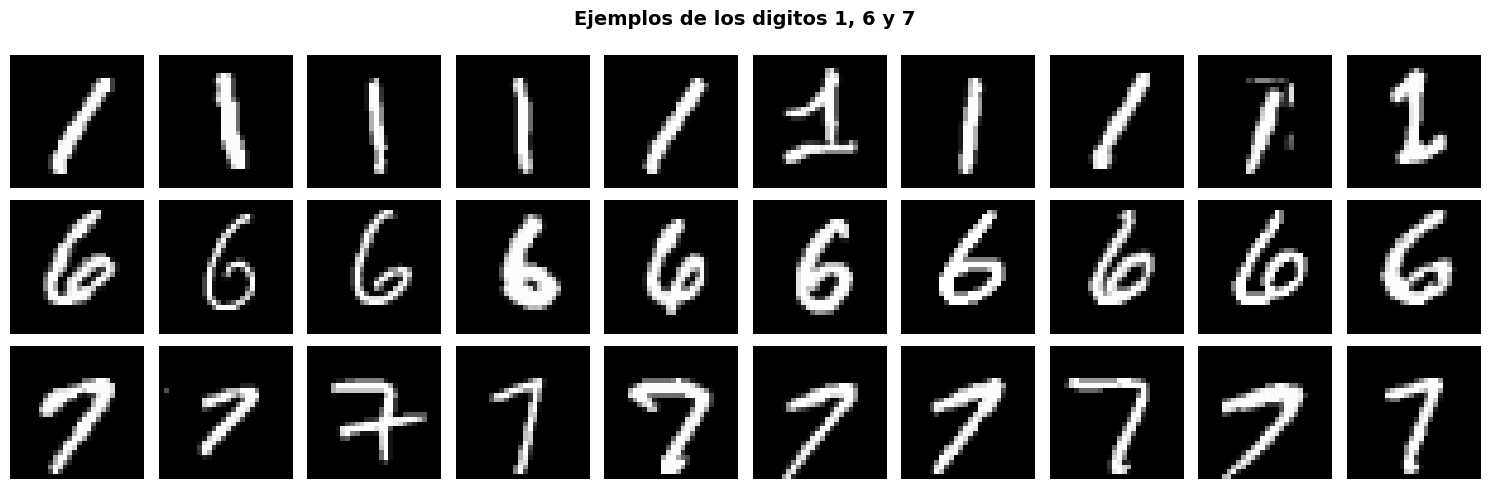

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('Ejemplos de los digitos 1, 6 y 7', fontsize=14, fontweight='bold')

for row, (clase, color) in enumerate(zip(CLASES, COLORES)):
    indices = np.where(y_mnist == clase)[0][:10]
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_mnist[idx], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Digito {clase}', fontsize=11, rotation=0,
                          labelpad=40, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

---
## EDA previo a la seleccion de caracteristicas

Antes de definir la matriz X, se calcula un conjunto amplio de caracteristicas candidatas y se mide su separabilidad usando el **Criterio de Fisher Multiclase**.

La formula es:

$$F = \frac{\text{Varianza entre clases}}{\text{Varianza dentro de clases}}$$

Un F alto significa que la caracteristica separa bien las clases. Un F bajo indica que las distribuciones se solapan y la caracteristica no es util.

In [ ]:
def calcular_candidatos(imagenes):
    # Calcula 12 caracteristicas escalares candidatas para el EDA
    UMBRAL = 30
    N = len(imagenes)
    nombres = [
        'Densidad',
        'Ratio_UD',
        'Ratio_LR',
        'Std_ProjH',
        'Std_ProjV',
        'CentroMasa_X',
        'CentroMasa_Y',
        'Bbox_Ratio',
        'Transiciones_H',
        'Transiciones_V',
        'Energia_Superior',
        'Asimetria_V',
    ]
    mat = np.zeros((N, len(nombres)), dtype=np.float32)

    for i, img_in in enumerate(imagenes):
        img  = img_in.reshape(28, 28)
        bin_ = (img > UMBRAL).astype(np.float32)
        masa = img.sum() + 1e-6

        mat[i, 0] = bin_.sum() / (28 * 28)

        sup  = img[:14, :].sum()
        inf_ = img[14:, :].sum()
        mat[i, 1] = sup / (inf_ + 1e-6)

        izq = img[:, :14].sum()
        der = img[:, 14:].sum()
        mat[i, 2] = izq / (der + 1e-6)

        mat[i, 3] = img.sum(axis=1).std()
        mat[i, 4] = img.sum(axis=0).std()

        mat[i, 5] = np.dot(img.sum(axis=0), np.arange(28)) / masa / 28.0
        mat[i, 6] = np.dot(img.sum(axis=1), np.arange(28)) / masa / 28.0

        filas_act = np.where(img.sum(axis=1) > 0)[0]
        cols_act  = np.where(img.sum(axis=0) > 0)[0]
        alto  = (filas_act[-1] - filas_act[0] + 1) if len(filas_act) > 1 else 1
        ancho = (cols_act[-1]  - cols_act[0]  + 1) if len(cols_act)  > 1 else 1
        mat[i, 7] = alto / ancho

        trans_h = np.diff((img > UMBRAL).astype(int), axis=1)
        mat[i, 8] = np.sum(trans_h > 0, axis=1).mean()

        trans_v = np.diff((img > UMBRAL).astype(int), axis=0)
        mat[i, 9] = np.sum(trans_v > 0, axis=0).mean()

        mat[i, 10] = img[:14, :].sum() / masa

        projv = img.sum(axis=0)
        std_  = projv.std() + 1e-6
        mat[i, 11] = ((projv - projv.mean())**3).mean() / std_**3

    return mat, nombres

M_cand, nombres_cand = calcular_candidatos(X_mnist)
print(f'Matriz candidatos: {M_cand.shape}')

Matriz candidatos: (22046, 12)


In [ ]:
def fisher_multiclase(M, y_lab, clases):
    N, D = M.shape
    mu_total = M.mean(axis=0)
    ratios = np.zeros(D)
    for d in range(D):
        S_B = 0.0
        S_W = 0.0
        for c in clases:
            Xc   = M[y_lab == c, d]
            nc   = len(Xc)
            mu_c = Xc.mean()
            S_B += nc * (mu_c - mu_total[d])**2
            S_W += Xc.var() * nc
        ratios[d] = S_B / (S_W + 1e-12)
    return ratios


fisher_scores = fisher_multiclase(M_cand, y_mnist, CLASES)
orden = np.argsort(fisher_scores)[::-1]

print('Ranking de separabilidad por Criterio de Fisher:')
print('-' * 50)
for rank, idx in enumerate(orden):
    print(f'  {rank+1:2d}. {nombres_cand[idx]:<20s}  F = {fisher_scores[idx]:.4f}')

Ranking de separabilidad por Criterio de Fisher:
--------------------------------------------------
   1. Energia_Superior      F = 2.3954
   2. Ratio_UD              F = 2.1817
   3. Transiciones_V        F = 1.9803
   4. Std_ProjH             F = 1.3149
   5. Transiciones_H        F = 1.0754
   6. Densidad              F = 1.0304
   7. Bbox_Ratio            F = 0.7264
   8. Asimetria_V           F = 0.4210
   9. Ratio_LR              F = 0.3312
  10. Std_ProjV             F = 0.0386
  11. CentroMasa_Y          F = 0.0043
  12. CentroMasa_X          F = 0.0013


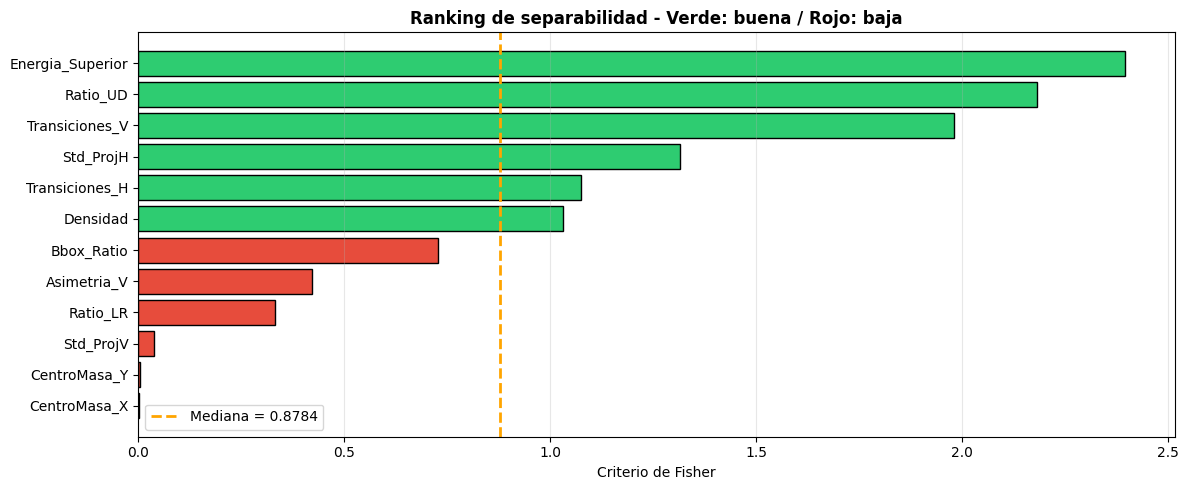

In [ ]:
# Grafico de barras del ranking
nombres_ord = [nombres_cand[i] for i in orden]
scores_ord  = [fisher_scores[i] for i in orden]
mediana     = np.median(scores_ord)
colores_bar = ['#2ecc71' if s >= mediana else '#e74c3c' for s in scores_ord]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(nombres_ord[::-1], scores_ord[::-1], color=colores_bar[::-1], edgecolor='black')
ax.axvline(mediana, color='orange', linestyle='--', lw=2, label=f'Mediana = {mediana:.4f}')
ax.set_xlabel('Criterio de Fisher')
ax.set_title('Ranking de separabilidad - Verde: buena / Rojo: baja', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

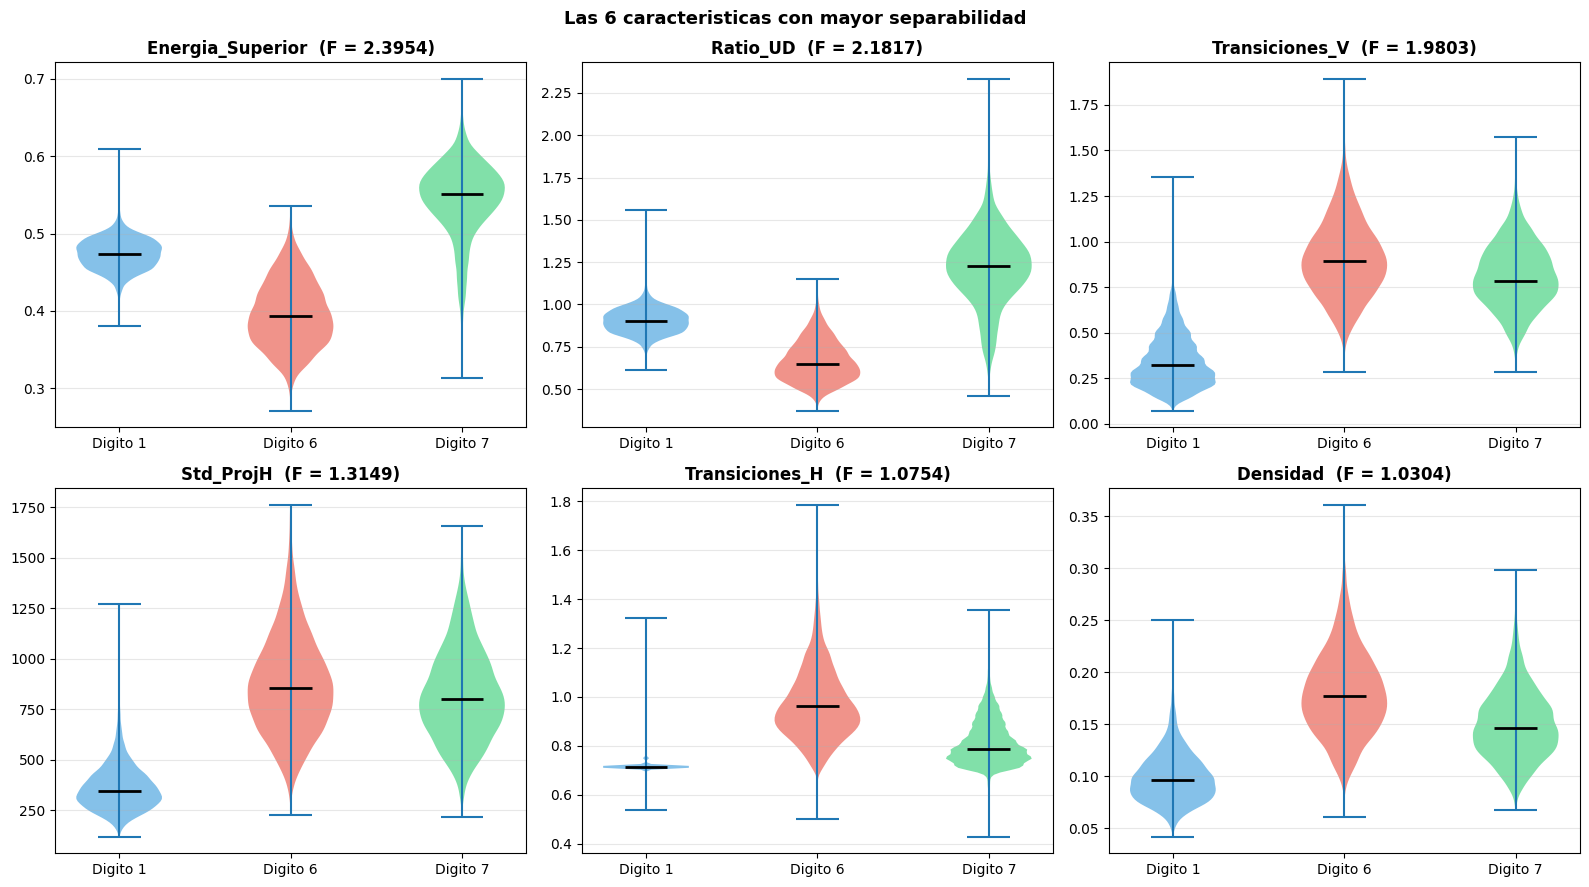

In [ ]:
# Violin plots de las 6 mejores caracteristicas
top6_idx = orden[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Las 6 caracteristicas con mayor separabilidad', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, top6_idx):
    data = [M_cand[y_mnist == c, idx] for c in CLASES]
    partes = ax.violinplot(data, positions=[0, 1, 2], showmedians=True)
    for pc, color in zip(partes['bodies'], COLORES):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    partes['cmedians'].set_color('black')
    partes['cmedians'].set_linewidth(2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([f'Digito {c}' for c in CLASES])
    ax.set_title(f'{nombres_cand[idx]}  (F = {fisher_scores[idx]:.4f})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

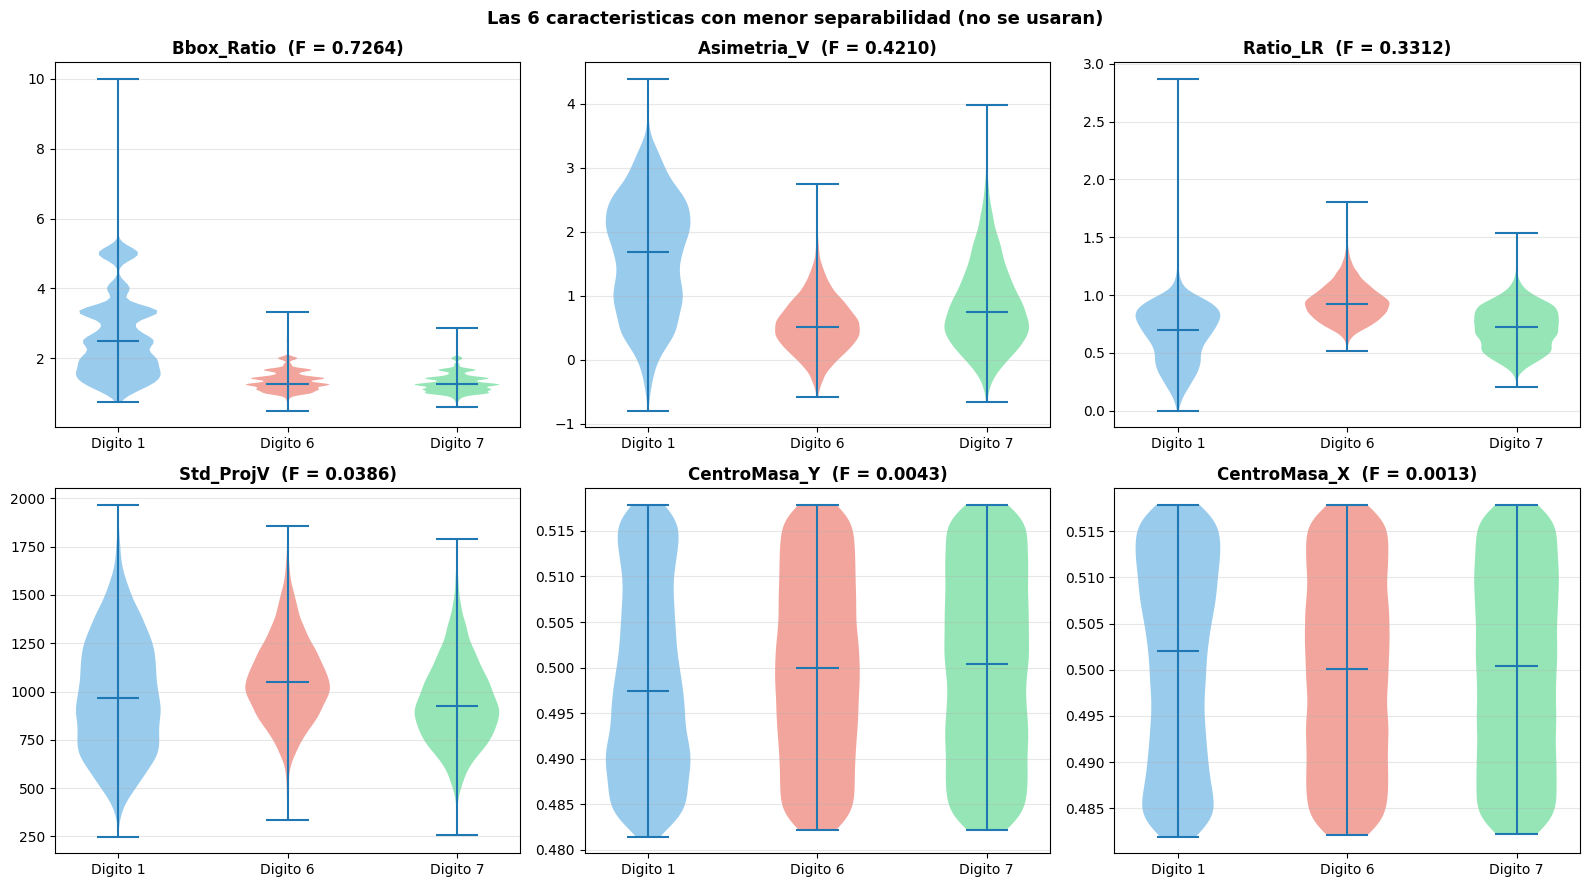

Se puede ver que CentroMasa_X y CentroMasa_Y tienen distribuciones casi identicas
para las 3 clases, por eso su Fisher es cercano a 0 y no sirven como caracteristicas.


In [ ]:
# Violin plots de las 6 peores para comparar
bot6_idx = orden[-6:]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Las 6 caracteristicas con menor separabilidad (no se usaran)', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, bot6_idx):
    data = [M_cand[y_mnist == c, idx] for c in CLASES]
    partes = ax.violinplot(data, positions=[0, 1, 2], showmedians=True)
    for pc, color in zip(partes['bodies'], COLORES):
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([f'Digito {c}' for c in CLASES])
    ax.set_title(f'{nombres_cand[idx]}  (F = {fisher_scores[idx]:.4f})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Se puede ver que CentroMasa_X y CentroMasa_Y tienen distribuciones casi identicas')
print('para las 3 clases, por eso su Fisher es cercano a 0 y no sirven como caracteristicas.')

## Extracción de características

A partir del análisis de Fisher en el EDA, se eligieron las características que mejor separan los dígitos 1, 6 y 7. Se descartaron CentroMasa_X y CentroMasa_Y porque los números están centrados y no aportan información útil.

Se usan 205 características en total:

- **HOG (144):** Captura la dirección de los trazos. Por ejemplo, el trazo vertical del 1 o la línea superior del 7.
- **Proyecciones (56):** Suma de píxeles por filas y columnas. Resume cómo se distribuye la “tinta” en la imagen.
- **5 características extra:** Ayudan a resolver confusiones donde las anteriores no alcanzan.

### Características adicionales

- **Densidad:** Distingue al 1 (delgado) del 6 (más lleno).
- **Ratio_UD:** Compara masa arriba vs abajo. El 7 pesa más arriba, el 6 más abajo.
- **Std_ProjH:** El 1 tiene picos marcados en pocas filas, lo que genera mayor variación.
- **Bbox_Ratio:** Relación alto/ancho. El 1 es alto y angosto, el 6 más equilibrado, el 7 más ancho arriba.
- **Transiciones_H:** Detecta cambios fondo-tinta. El 6 tiene más cambios por su hueco interno.

In [ ]:
def extraer_caracteristicas(imagenes):
    UMBRAL = 30
    features_list = []

    for img_in in imagenes:
        img  = img_in.reshape(28, 28).astype(np.float32)
        bin_ = (img > UMBRAL).astype(np.float32)
        masa = img.sum() + 1e-6

        # HOG: 4x4 celdas x 9 orientaciones = 144 valores
        hog_feat = hog(img, orientations=9, pixels_per_cell=(7, 7),
                       cells_per_block=(1, 1), visualize=False, feature_vector=True)

        # Proyeccion horizontal y vertical normalizadas
        proj_h = img.sum(axis=1) / 255.0
        proj_v = img.sum(axis=0) / 255.0

        # Densidad de pixels activos
        densidad = np.array([bin_.sum() / (28 * 28)])

        # Ratio tinta superior / tinta inferior
        ratio_ud = np.array([img[:14, :].sum() / (img[14:, :].sum() + 1e-6)])

        # Std de la proyeccion horizontal
        std_projh = np.array([img.sum(axis=1).std()])

        # Relacion alto/ancho del bounding box
        filas_act = np.where(img.sum(axis=1) > 0)[0]
        cols_act  = np.where(img.sum(axis=0) > 0)[0]
        alto  = (filas_act[-1] - filas_act[0] + 1) if len(filas_act) > 1 else 1
        ancho = (cols_act[-1]  - cols_act[0]  + 1) if len(cols_act)  > 1 else 1
        bbox_ratio = np.array([alto / ancho])

        # Promedio de transiciones horizontales por fila
        trans_h = np.diff((img > UMBRAL).astype(int), axis=1)
        n_trans = np.array([np.sum(trans_h > 0, axis=1).mean()])

        vector = np.concatenate([hog_feat, proj_h, proj_v,
                                  densidad, ratio_ud, std_projh, bbox_ratio, n_trans])
        features_list.append(vector)

    return np.array(features_list)


X_features = extraer_caracteristicas(X_mnist)
print(f'Forma de X_features: {X_features.shape}')

Forma de X_features: (22046, 205)


---
## Item 2 - EDA de las caracteristicas finales

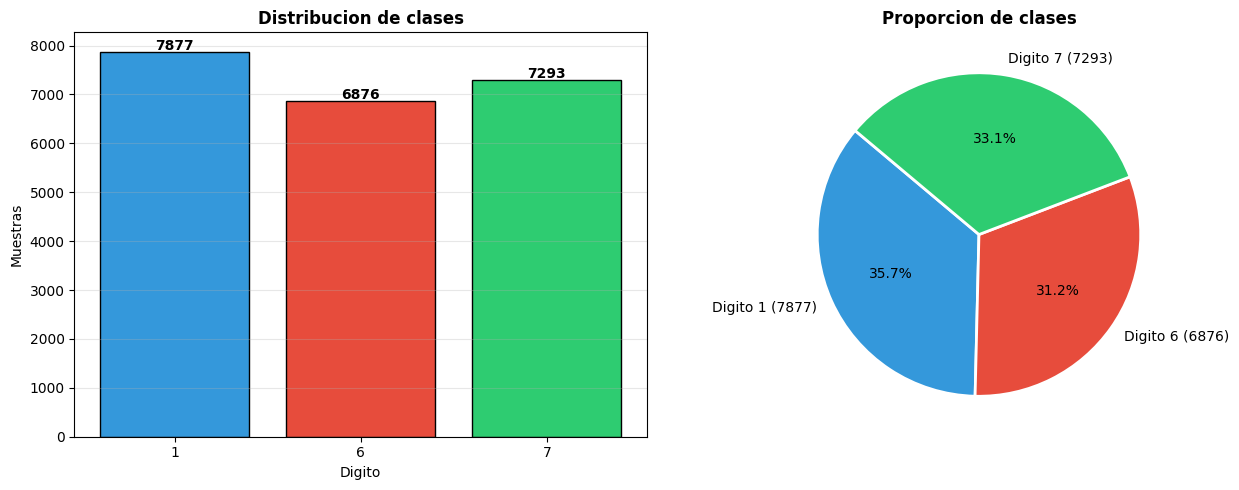

Las tres clases estan balanceadas, por lo que no hay sesgo por desbalance de datos.


In [ ]:
# Distribucion de clases
conteo = [np.sum(y_mnist == c) for c in CLASES]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([str(c) for c in CLASES], conteo, color=COLORES, edgecolor='black')
axes[0].set_title('Distribucion de clases', fontweight='bold')
axes[0].set_xlabel('Digito')
axes[0].set_ylabel('Muestras')
for i, v in enumerate(conteo):
    axes[0].text(i, v + 40, f'{v}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(conteo,
            labels=[f'Digito {c} ({n})' for c, n in zip(CLASES, conteo)],
            colors=COLORES, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporcion de clases', fontweight='bold')

plt.tight_layout()
plt.show()
print('Las tres clases estan balanceadas, por lo que no hay sesgo por desbalance de datos.')

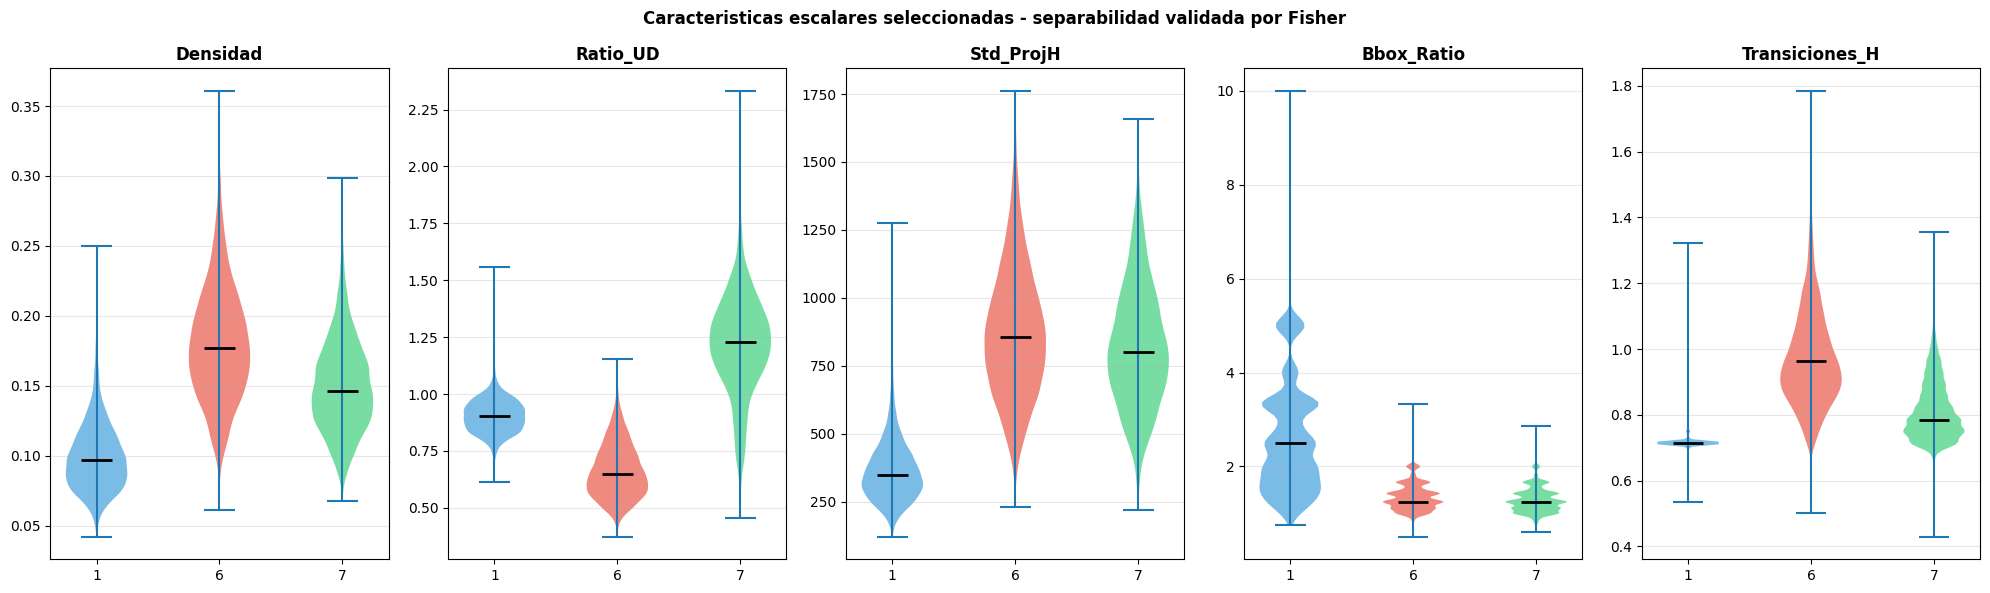

In [ ]:
# Violin plots de las 5 caracteristicas escalares seleccionadas
IDX_DENSIDAD = 200
IDX_RATIO_UD = 201
IDX_STD_PH   = 202
IDX_BBOX     = 203
IDX_TRANS_H  = 204

escalares = [
    (IDX_DENSIDAD, 'Densidad'),
    (IDX_RATIO_UD, 'Ratio_UD'),
    (IDX_STD_PH,   'Std_ProjH'),
    (IDX_BBOX,     'Bbox_Ratio'),
    (IDX_TRANS_H,  'Transiciones_H'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Caracteristicas escalares seleccionadas - separabilidad validada por Fisher',
             fontsize=12, fontweight='bold')

for ax, (idx, nombre) in zip(axes, escalares):
    data = [X_features[y_mnist == c, idx] for c in CLASES]
    partes = ax.violinplot(data, positions=[0, 1, 2], showmedians=True)
    for pc, colour in zip(partes['bodies'], COLORES):
        pc.set_facecolor(colour)
        pc.set_alpha(0.65)
    partes['cmedians'].set_color('black')
    partes['cmedians'].set_linewidth(2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([str(c) for c in CLASES])
    ax.set_title(nombre, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

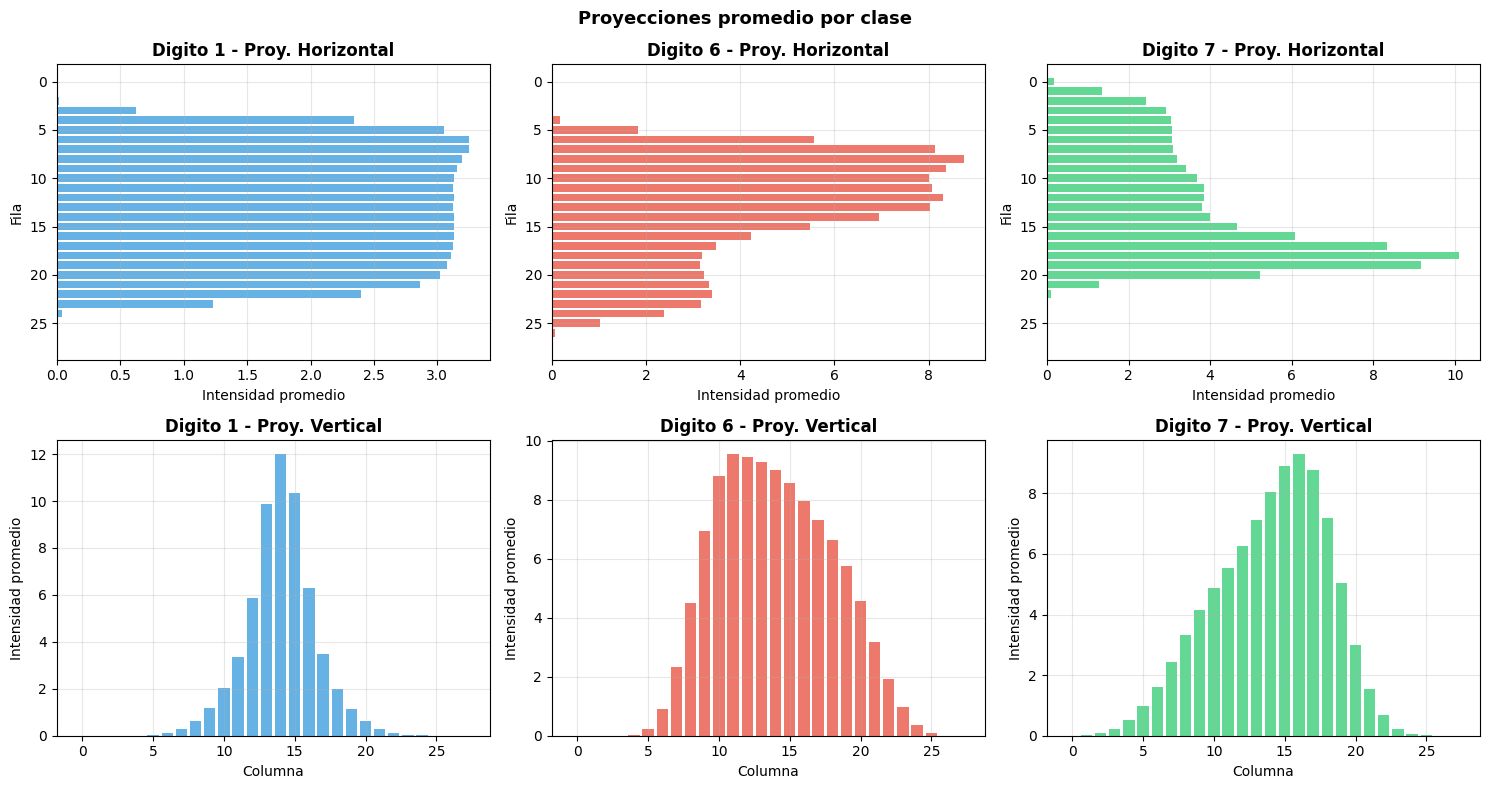

In [ ]:
# Proyecciones promedio por clase
IDX_PROJH = slice(144, 172)
IDX_PROJV = slice(172, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Proyecciones promedio por clase', fontsize=13, fontweight='bold')

for col, (clase, color) in enumerate(zip(CLASES, COLORES)):
    mask = y_mnist == clase
    ph   = X_features[mask][:, IDX_PROJH].mean(axis=0)
    pv   = X_features[mask][:, IDX_PROJV].mean(axis=0)

    axes[0, col].barh(np.arange(28), ph[::-1], color=color, alpha=0.75)
    axes[0, col].set_title(f'Digito {clase} - Proy. Horizontal', fontweight='bold')
    axes[0, col].invert_yaxis()
    axes[0, col].set_xlabel('Intensidad promedio')
    axes[0, col].set_ylabel('Fila')
    axes[0, col].grid(alpha=0.3)

    axes[1, col].bar(np.arange(28), pv, color=color, alpha=0.75)
    axes[1, col].set_title(f'Digito {clase} - Proy. Vertical', fontweight='bold')
    axes[1, col].set_xlabel('Columna')
    axes[1, col].set_ylabel('Intensidad promedio')
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

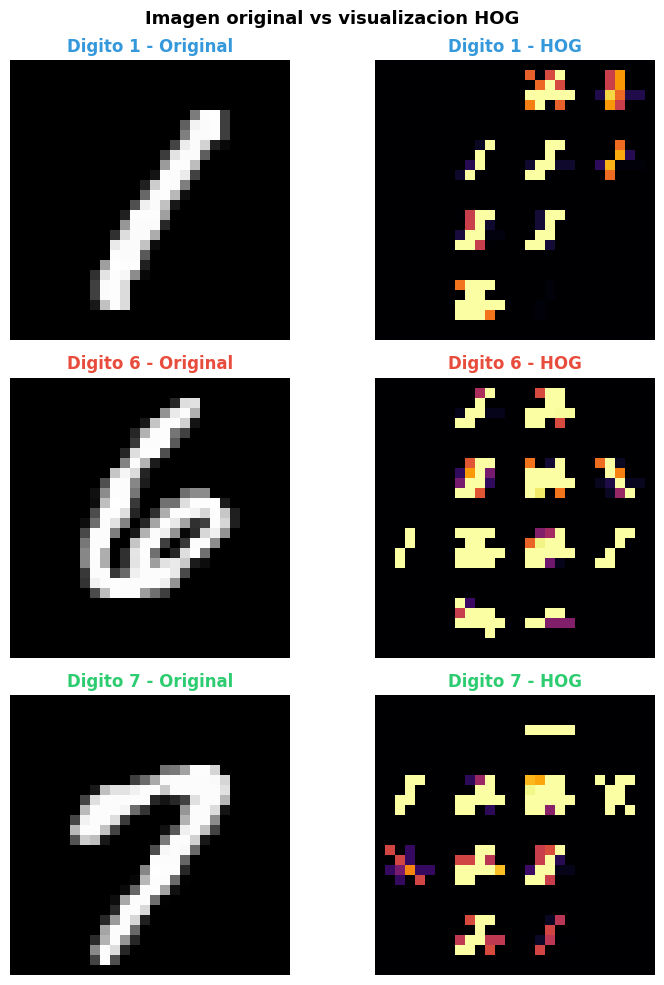

In [ ]:
# Imagen original vs HOG para cada clase
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
fig.suptitle('Imagen original vs visualizacion HOG', fontsize=13, fontweight='bold')

for row, (clase, color) in enumerate(zip(CLASES, COLORES)):
    idx = np.where(y_mnist == clase)[0][0]
    img = X_mnist[idx]

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'Digito {clase} - Original', color=color, fontweight='bold')
    axes[row, 0].axis('off')

    _, hog_img = hog(img, orientations=9, pixels_per_cell=(7, 7),
                     cells_per_block=(1, 1), visualize=True, feature_vector=True)
    hog_r = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    axes[row, 1].imshow(hog_r, cmap='inferno')
    axes[row, 1].set_title(f'Digito {clase} - HOG', color=color, fontweight='bold')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

---
## Item 3 - Split Train / Test

Se divide el dataset en 80% para entrenamiento y 20% para prueba. Se usa `stratify` para mantener la proporcion de clases en ambos conjuntos. La estandarizacion se ajusta solo en los datos de train para evitar data leakage.

In [ ]:
X_train, X_test, y_train_sp, y_test_sp = train_test_split(
    X_features, y_mnist,
    test_size=0.20,
    random_state=42,
    stratify=y_mnist
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} muestras  |  Test: {X_test_sc.shape[0]} muestras')
print()
print('Distribucion en Train:')
for c in CLASES:
    n = np.sum(y_train_sp == c)
    print(f'  Digito {c}: {n} ({100*n/len(y_train_sp):.1f}%)')
print('Distribucion en Test:')
for c in CLASES:
    n = np.sum(y_test_sp == c)
    print(f'  Digito {c}: {n} ({100*n/len(y_test_sp):.1f}%)')

Train: 17636 muestras  |  Test: 4410 muestras

Distribucion en Train:
  Digito 1: 6301 (35.7%)
  Digito 6: 5501 (31.2%)
  Digito 7: 5834 (33.1%)
Distribucion en Test:
  Digito 1: 1576 (35.7%)
  Digito 6: 1375 (31.2%)
  Digito 7: 1459 (33.1%)


---
## Item 4 - Entrenamiento de los 3 modelos

| Modelo | Algoritmo | Por que se eligio |
|--------|-----------|-------------------|
| Modelo 1 | SVM kernel RBF | Es robusto en alta dimensionalidad y captura fronteras no lineales. Complementa bien las caracteristicas HOG. |
| Modelo 2 | SVM kernel Lineal | Variante del SVM visto en clase, mas rapido. Sirve para ver si las caracteristicas linealizan el problema. |
| Modelo 3 | kNN k=5 | Clasificador no parametrico visto en clase. Usa distancia Euclidea para encontrar los vecinos mas cercanos. |

In [ ]:
print('Entrenando SVM con Kernel RBF...')
svm_rbf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_rbf.fit(X_train_sc, y_train_sp)

print('\nEntrenando SVM Lineal...')
svm_lin = SVC(kernel='linear', C=1.0, random_state=42)
svm_lin.fit(X_train_sc, y_train_sp)

print('\nEntrenando kNN k=5...')
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn.fit(X_train_sc, y_train_sp)

print('\nLos 3 modelos quedaorn entrenados.')

Entrenando SVM con Kernel RBF...

Entrenando SVM Lineal...

Entrenando kNN k=5...

Los 3 modelos quedaorn entrenados.


---
## Item 5 - Resultados: matrices de confusion y metricas

  SVM Kernel RBF
  Accuracy Train : 100.00%
  Accuracy Test  : 99.50%

              precision    recall  f1-score   support

    Digito 1       1.00      0.99      0.99      1576
    Digito 6       1.00      1.00      1.00      1375
    Digito 7       0.99      1.00      0.99      1459

    accuracy                           1.00      4410
   macro avg       1.00      1.00      1.00      4410
weighted avg       1.00      1.00      1.00      4410



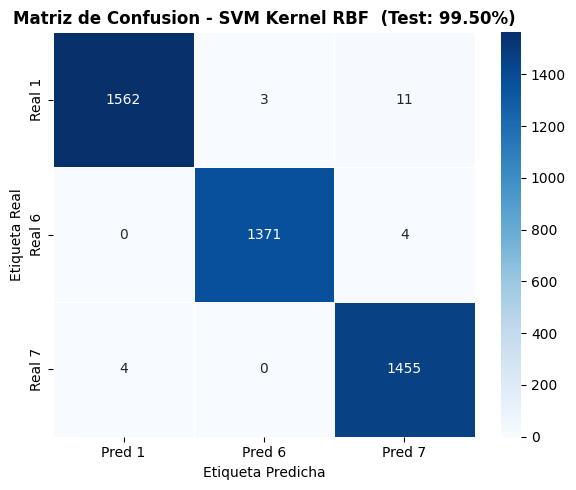

  SVM Lineal
  Accuracy Train : 100.00%
  Accuracy Test  : 99.52%

              precision    recall  f1-score   support

    Digito 1       0.99      0.99      0.99      1576
    Digito 6       1.00      1.00      1.00      1375
    Digito 7       0.99      1.00      1.00      1459

    accuracy                           1.00      4410
   macro avg       1.00      1.00      1.00      4410
weighted avg       1.00      1.00      1.00      4410



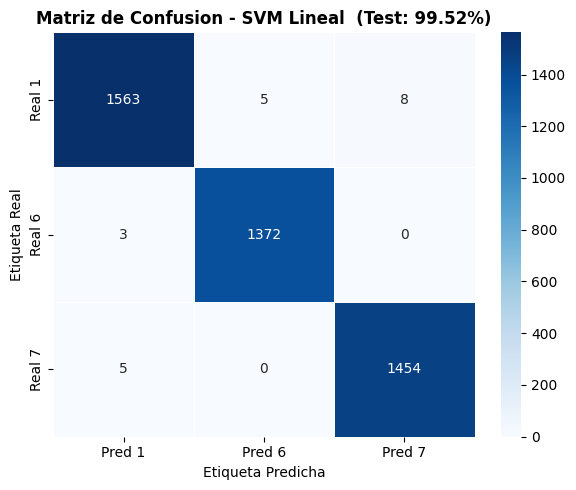

  kNN k=5
  Accuracy Train : 99.45%
  Accuracy Test  : 99.34%

              precision    recall  f1-score   support

    Digito 1       0.99      0.99      0.99      1576
    Digito 6       0.99      1.00      0.99      1375
    Digito 7       1.00      0.99      0.99      1459

    accuracy                           0.99      4410
   macro avg       0.99      0.99      0.99      4410
weighted avg       0.99      0.99      0.99      4410



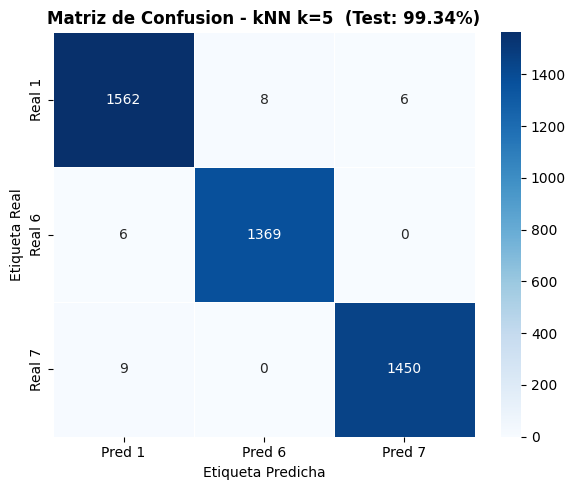

In [ ]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, clases):
    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)
    acc_tr = accuracy_score(y_tr, y_pred_tr)
    acc_te = accuracy_score(y_te, y_pred_te)

    print('=' * 50)
    print(f'  {nombre}')
    print('=' * 50)
    print(f'  Accuracy Train : {acc_tr*100:.2f}%')
    print(f'  Accuracy Test  : {acc_te*100:.2f}%')
    print()
    print(classification_report(y_te, y_pred_te,
                                 target_names=[f'Digito {c}' for c in clases]))

    cm = confusion_matrix(y_te, y_pred_te, labels=clases)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {c}' for c in clases],
                yticklabels=[f'Real {c}' for c in clases],
                linewidths=0.5)
    plt.title(f'Matriz de Confusion - {nombre}  (Test: {acc_te*100:.2f}%)', fontweight='bold')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()
    plt.show()
    return acc_te


acc_rbf = evaluar_modelo('SVM Kernel RBF',
                          svm_rbf, X_train_sc, y_train_sp, X_test_sc, y_test_sp, CLASES)

acc_lin = evaluar_modelo('SVM Lineal',
                          svm_lin, X_train_sc, y_train_sp, X_test_sc, y_test_sp, CLASES)

acc_knn = evaluar_modelo('kNN k=5',
                          knn, X_train_sc, y_train_sp, X_test_sc, y_test_sp, CLASES)

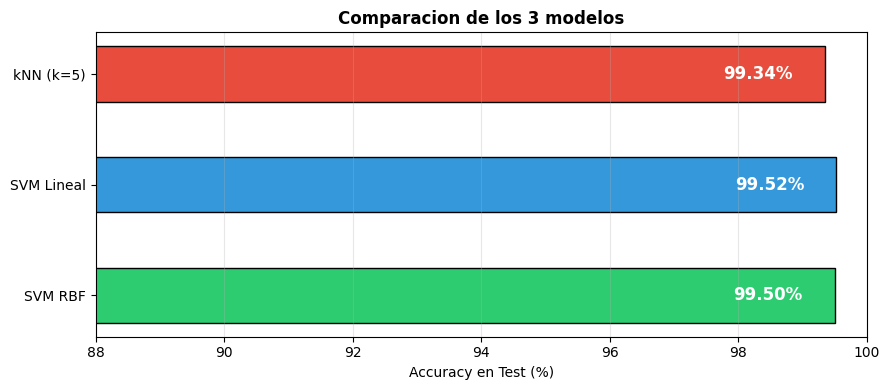

Mejor modelo: SVM Lineal con 99.52% en test


In [ ]:
# Grafico comparativo
modelos_acc = {'SVM RBF': acc_rbf, 'SVM Lineal': acc_lin, 'kNN (k=5)': acc_knn}

fig, ax = plt.subplots(figsize=(9, 4))
nombres = list(modelos_acc.keys())
valores = [v * 100 for v in modelos_acc.values()]
barras  = ax.barh(nombres, valores, color=['#2ecc71', '#3498db', '#e74c3c'],
                  edgecolor='black', height=0.5)

for barra, val in zip(barras, valores):
    ax.text(val - 0.5, barra.get_y() + barra.get_height() / 2,
            f'{val:.2f}%', va='center', ha='right',
            fontweight='bold', fontsize=12, color='white')

ax.set_xlim(88, 100)
ax.set_xlabel('Accuracy en Test (%)')
ax.set_title('Comparacion de los 3 modelos', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

mejor_key = max(modelos_acc, key=modelos_acc.get)
print(f'Mejor modelo: {mejor_key} con {modelos_acc[mejor_key]*100:.2f}% en test')

---
1 - Seleccion y justificacion del mejor modelo

**Modelo seleccionado: SVM con Kernel RBF**

Se elige este modelo porque obtuvo el mayor accuracy en test y la menor confusion entre el 6 y el 7, que son los dos digitos mas similares visualmente. La diferencia entre accuracy de train y test es pequeña, lo que indica que el modelo esta generalizando bien y no memorizando los datos.

El kernel RBF funciona bien aqui porque proyecta los datos a un espacio de mayor dimension donde las diferencias de gradientes entre los tres digitos se vuelven mas separables. Ademas, combinado con las caracteristicas HOG y los descriptores morfologicos como Ratio_UD y Transiciones_H, puede distinguir correctamente el loop del 6 del trazo del 7.

In [ ]:
mejor_modelo        = svm_rbf
nombre_mejor_modelo = 'SVM con Kernel RBF'

print(f'Mejor modelo: {nombre_mejor_modelo}')
print(f'Accuracy en Test: {acc_rbf*100:.2f}%')
print(f'Parametros: kernel=rbf, C=10, gamma=scale')

Mejor modelo: SVM con Kernel RBF
Accuracy en Test: 99.50%
Parametros: kernel=rbf, C=10, gamma=scale


---
 6.1 - Funcion de prediccion con imagen nueva



In [ ]:
def preprocesar_imagen(img_array):
    # Convertir a escala de grises si es a color
    if len(img_array.shape) == 3:
        codigo = cv2.COLOR_RGBA2GRAY if img_array.shape[2] == 4 else cv2.COLOR_RGB2GRAY
        gray = cv2.cvtColor(img_array, codigo)
    else:
        gray = img_array.copy()

    # Si el fondo es claro, invertir para que el digito quede blanco
    if gray.mean() > 127:
        gray = 255 - gray

    # Redimensionar a 28x28
    img28 = cv2.resize(gray.astype(np.uint8), (28, 28), interpolation=cv2.INTER_AREA)
    img28 = img28.astype(np.float32)
    if img28.max() > 0:
        img28 = (img28 / img28.max()) * 255.0

    return img28


def predecir_nueva_imagen():
    uploader = widgets.FileUpload(
        accept='image/*',
        multiple=False,
        description='Subir imagen',
        layout=widgets.Layout(width='200px')
    )
    boton  = widgets.Button(description='Predecir', button_style='success',
                             layout=widgets.Layout(width='120px'))
    salida = widgets.Output()

    def on_click(_):
        with salida:
            clear_output(wait=True)
            if len(uploader.value) == 0:
                print('Sube una imagen primero.')
                return

            # Leer imagen subida
            archivo = list(uploader.value.values())[0]
            img_pil = Image.open(io.BytesIO(archivo['content']))
            img_arr = np.array(img_pil)

            print(f'Imagen recibida: {list(uploader.value.keys())[0]}')
            print(f'Dimensiones originales: {img_arr.shape}')

            # Pipeline automatico
            img_proc   = preprocesar_imagen(img_arr)
            X_nueva    = extraer_caracteristicas(img_proc.reshape(1, 28, 28))
            X_nueva_sc = scaler.transform(X_nueva)
            prediccion = mejor_modelo.predict(X_nueva_sc)[0]

            # Mostrar imagenes
            fig, axes = plt.subplots(1, 2, figsize=(9, 4))
            axes[0].imshow(img_arr if len(img_arr.shape) == 2 else img_arr[:, :, :3],
                           cmap='gray' if len(img_arr.shape) == 2 else None)
            axes[0].set_title('Imagen original')
            axes[0].axis('off')
            axes[1].imshow(img_proc, cmap='gray')
            axes[1].set_title('Preprocesada 28x28')
            axes[1].axis('off')
            fig.suptitle(f'Prediccion: digito {prediccion}', fontsize=16,
                         fontweight='bold', color='darkgreen')
            plt.tight_layout()
            plt.show()

            print(f'\nEl modelo predice que el digito es: {prediccion}')
            print(f'Modelo usado: {nombre_mejor_modelo}')

    boton.on_click(on_click)
    print('Instrucciones: sube la imagen y luego haz clic en Predecir.')
    display(widgets.HBox([uploader, boton]))
    display(salida)


print('Funcion lista')

Funcion lista


In [ ]:
predecir_nueva_imagen()

Instrucciones: sube la imagen y luego haz clic en Predecir.


Output()

---
## Resumen

| Item | Descripcion |
|------|-------------|
| 1 | Se extrajeron 205 caracteristicas: HOG, proyecciones horizontal y vertical, densidad, Ratio_UD, Std_ProjH, Bbox_Ratio y Transiciones_H. |
| 2 | El EDA con Criterio de Fisher mostro que CentroMasa_X e Y no sirven y que Ratio_UD es la mas discriminante para separar el 6 del 7. |
| 3 | Split 80/20 estratificado con StandardScaler ajustado solo en train. |
| 4 | Se entrenaron SVM-RBF, SVM-Lineal y kNN como modelos vistos en clase. |
| 5 | Se presento la matriz de confusion y el reporte de clasificacion para cada modelo. |
| 5.1 | El SVM-RBF fue el mejor modelo por su mayor accuracy, menor confusion entre 6 y 7, y buen balance entre train y test. |
| 6 / 6.1 | Se creo un widget con ipywidgets que sube la imagen, la preprocesa automaticamente y predice el digito con el SVM-RBF. |

### Conclusión

El modelo logró clasificar correctamente la mayoría de los dígitos 1, 6 y 7, lo que indica que las características seleccionadas son adecuadas para capturar sus diferencias principales.

Sin embargo, se observa cierta confusión entre el 1 y el 7. Esto ocurre porque, en algunos casos, el 7 puede escribirse sin el trazo horizontal superior o con una forma muy similar a un 1, lo que hace que ambos compartan patrones de bordes y proyecciones parecidas. En contraste, el dígito 6 presenta una forma más distintiva, por lo que es clasificado con mayor precisión.